In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Fijar semilla global para reproducibilidad
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Importar las arquitecturas desde models.py
from models import SimpleMLP, RegularizedMLP, DeepMLP

In [2]:
data = pd.read_csv("Pokemon.csv")
data.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


## Descripción de la tarea

Trabajaremos con un dataset de la serie "Pokémon" que desglosa las capacidades de cada criatura en atributos cuantitativos. La tarea consiste en utilizar arquitecturas de redes neuronales simples (MLP) para identificar patrones que distingan a los Pokémon Legendarios del resto. Deberán procesar estas variables y entrenar un clasificador que maximice la capacidad predictiva sobre la variable objetivo "Legendary".

Consideraciones:
- Debe entregarlo a más tardar el 29 de mayo a las 18:00 horas.
- Debe ser entregado al correo luis.llanca@uach.cl con el asunto "Tarea-1-MLP", el archivo debe llamarse NG-MLP-Tarea1.ipynb donde NG es el número de grupo. Es importante que el asunto sea exactamente el mismo. También, se les pedirá que se anoten en la plantilla (que se compartirá posteriormente) para una pequeña interrogación.
- Por cada 20 minutos de retraso, se descontará una décima de la nota. 
- Si necesitan ayuda, pueden escribir a los correos luis.llanca@uach.cl, luis.llanca@cenia.cl o escribir al discord de usuario: llanking (tengo una foto de mi gata). PD: prefiero mucho más el discord. 

### Explicación del dataset
Explique el dataset en detalle, incluyendo como mínimo una pequeña descripción de cada columna, el tipo de datos que contiene cada columna, y cualquier información adicional relevante para entender el dataset.

In [3]:
# Análisis exploratorio básico
print("--- Información General del Dataset ---")
print(data.info())

print("\n--- Primeras filas del dataset ---")
display(data.head())

print("\n--- Estadísticas descriptivas generales ---")
display(data.describe(include='all'))

print("\n--- Distribución de la variable objetivo (Legendary) ---")
print(data['Legendary'].value_counts())
print(data['Legendary'].value_counts(normalize=True))

--- Información General del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        800 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      414 non-null    object
 4   Total       800 non-null    int64 
 5   HP          800 non-null    int64 
 6   Attack      800 non-null    int64 
 7   Defense     800 non-null    int64 
 8   Sp. Atk     800 non-null    int64 
 9   Sp. Def     800 non-null    int64 
 10  Speed       800 non-null    int64 
 11  Generation  800 non-null    int64 
 12  Legendary   800 non-null    bool  
dtypes: bool(1), int64(9), object(3)
memory usage: 75.9+ KB
None

--- Primeras filas del dataset ---


,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False



--- Estadísticas descriptivas generales ---


,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
count,800.000000,800,800,414,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000,800
unique,NaN,800,18,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,PumpkabooSuper Size,Water,Flying,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
freq,NaN,1,112,97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,735
mean,362.813750,NaN,NaN,NaN,435.10250,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375,NaN
std,208.343798,NaN,NaN,NaN,119.96304,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129,NaN
min,1.000000,NaN,NaN,NaN,180.00000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000,NaN
25%,184.750000,NaN,NaN,NaN,330.00000,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000,NaN
50%,364.500000,NaN,NaN,NaN,450.00000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000,NaN
75%,539.250000,NaN,NaN,NaN,515.00000,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000,NaN



--- Distribución de la variable objetivo (Legendary) ---
Legendary
False    735
True      65
Name: count, dtype: int64
Legendary
False    0.91875
True     0.08125
Name: proportion, dtype: float64


### Explicación de las variables y columnas:

1. **`#` (ID o Número de Pokédex):** Identificador ordinal del Pokémon. Es importante notar que no es un índice único puro; múltiples filas pueden compartir el mismo `#` si corresponden a Mega-Evoluciones o formas alternativas de un mismo Pokémon (ej. Venusaur y Mega-Venusaur comparten el `#` 3). Esto es crucial para el modelamiento ya que puede causar fuga de datos si se realiza un split aleatorio simple.
2. **`Name`:** El nombre del Pokémon (tipo `object`/string). Es un identificador de texto único para cada fila.
3. **`Type 1`:** El tipo principal del Pokémon (ej. Grass, Fire, Water). Es una variable categórica nominal.
4. **`Type 2`:** El tipo secundario del Pokémon. Posee muchos valores nulos (`NaN`) debido a que no todos los Pokémon tienen doble tipo. Es una variable categórica nominal.
5. **`Total`:** La suma de todas las estadísticas de combate (HP, Attack, Defense, Sp. Atk, Sp. Def, Speed). Es una variable cuantitativa continua y suele ser el predictor más fuerte de si un Pokémon es legendario.
6. **`HP` (Puntos de Salud):** Estadística cuantitativa que representa la salud base del Pokémon.
7. **`Attack` (Ataque):** Estadística cuantitativa de la fuerza de ataques físicos base del Pokémon.
8. **`Defense` (Defensa):** Estadística cuantitativa de resistencia física base del Pokémon.
9. **`Sp. Atk` (Ataque Especial):** Estadística cuantitativa de la fuerza de ataques especiales base del Pokémon.
10. **`Sp. Def` (Defensa Especial):** Estadística cuantitativa de resistencia especial base del Pokémon.
11. **`Speed` (Velocidad):** Estadística cuantitativa de la velocidad base del Pokémon, que determina quién ataca primero.
12. **`Generation`:** La generación en la que se introdujo el Pokémon (del 1 al 6). Aunque se carga como entero (`int64`), conceptualmente es una **variable categórica (ordinal/nominal)**.
13. **`Legendary` (Variable Objetivo):** Variable binaria/booleana que indica si el Pokémon tiene categoría de legendario (`True`) o no (`False`). Esta clase está fuertemente desbalanceada: solo 65 de las 800 filas corresponden a legendarios (~8.12%).

### Preparación del dataset

Realice una preparación del dataset según lo que considere necesario para el entrenamiento de un modelo de clasificación. Justifique las decisiones que tome en este proceso.

In [4]:
# 1. Tratamiento de nulos en Type 2
data_cleaned = data.copy()
data_cleaned['Type 2'] = data_cleaned['Type 2'].fillna('None')

# 2. Prevención de Fuga de Datos (Data Leakage) por Mega-Evoluciones y Formas Alternas
# Agrupamos los conjuntos de datos en base al ID del Pokédex (#), garantizando que todas las formas
# de un mismo Pokémon queden en el mismo conjunto de datos (Train, Val o Test).
unique_ids = data_cleaned['#'].unique()
np.random.seed(42) # Semilla local para consistencia en la mezcla de IDs
np.random.shuffle(unique_ids)

# Partición 80% train_ids y 20% test_ids
split_idx = int(len(unique_ids) * 0.8)
train_ids = unique_ids[:split_idx]
test_ids = unique_ids[split_idx:]

# Dividimos los IDs de entrenamiento en sub-entrenamiento (80%) y validación (20%)
val_split_idx = int(len(train_ids) * 0.8)
train_sub_ids = train_ids[:val_split_idx]
val_ids = train_ids[val_split_idx:]

print(f"Cantidad de IDs únicos - Train: {len(train_sub_ids)}, Val: {len(val_ids)}, Test: {len(test_ids)}")

# Mapear los IDs de vuelta al DataFrame para obtener los subconjuntos de datos correspondientes
train_df = data_cleaned[data_cleaned['#'].isin(train_sub_ids)].copy()
val_df = data_cleaned[data_cleaned['#'].isin(val_ids)].copy()
test_df = data_cleaned[data_cleaned['#'].isin(test_ids)].copy()

print(f"Filas resultantes - Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# 3. Codificación de Variables Categóricas (One-Hot Encoding)
# Aplicamos pd.get_dummies en el dataset completo para alinear las columnas y evitar diferencias de dimensiones
categorical_cols = ['Type 1', 'Type 2', 'Generation']
data_encoded = pd.get_dummies(data_cleaned, columns=categorical_cols, dtype=float)

# Remover variables no predictivas / identificadores
features_to_drop = ['#', 'Name', 'Legendary']
feature_cols = [col for col in data_encoded.columns if col not in features_to_drop]

# Separar variables independientes (X) y dependiente (y)
X = data_encoded[feature_cols].copy()
y = data_encoded['Legendary'].astype(float).copy()

# Dividir arrays según las máscaras de IDs
X_train = X[data_encoded['#'].isin(train_sub_ids)].values
y_train = y[data_encoded['#'].isin(train_sub_ids)].values

X_val = X[data_encoded['#'].isin(val_ids)].values
y_val = y[data_encoded['#'].isin(val_ids)].values

X_test = X[data_encoded['#'].isin(test_ids)].values
y_test = y[data_encoded['#'].isin(test_ids)].values

# 4. Escalamiento de Características Numéricas
# Escalar HP, Attack, Defense, Sp. Atk, Sp. Def, Speed, Total
numeric_features = ['Total', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']
numeric_indices = [feature_cols.index(col) for col in numeric_features]

scaler = StandardScaler()
# AJUSTAR EL SCALER SOLO CON LOS DATOS DE ENTRENAMIENTO (Evita fuga de información en el escalamiento)
X_train[:, numeric_indices] = scaler.fit_transform(X_train[:, numeric_indices])
X_val[:, numeric_indices] = scaler.transform(X_val[:, numeric_indices])
X_test[:, numeric_indices] = scaler.transform(X_test[:, numeric_indices])

# 5. Crear Dataset y DataLoader en PyTorch
class PokemonDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
        
    def __len__(self):
        return len(self.X)
        
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Fijar el generador de PyTorch para el shuffle determinista
g = torch.Generator()
g.manual_seed(42)

train_dataset = PokemonDataset(X_train, y_train)
val_dataset = PokemonDataset(X_val, y_val)
test_dataset = PokemonDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, generator=g)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Dimensión de entrada de la red: {X_train.shape[1]}")

Cantidad de IDs únicos - Train: 460, Val: 116, Test: 145
Filas resultantes - Train: 514, Val: 127, Test: 159
Dimensión de entrada de la red: 50


### Decisiones de Preparación y Preprocesamiento:

1.  **Tratamiento de `Type 2` Nulos:** Para no perder filas y conservar la información del segundo tipo elemental, se imputó el valor nulo con la categoría `'None'`. Al aplicar One-Hot encoding, esta categoría se representará como una columna dummy más.
2.  **Prevención de Fuga de Datos (Mega-Evoluciones):** En lugar de hacer un train/test split aleatorio simple, se implementó una partición agrupada por Pokédex `#`. Dado que un Pokémon y su Mega-Evolución comparten el mismo número de Pokédex, esto asegura que si, por ejemplo, `Charizard` se asigna a entrenamiento, sus Mega-Evoluciones (`CharizardMega Charizard X` y `CharizardMega Charizard Y`) también queden en entrenamiento. Si no hiciéramos esto, el modelo evaluaría con datos que ya memorizó debido a la gran similitud de sus nombres y estadísticas, inflando de manera artificial el desempeño (fuga de datos).
3.  **One-Hot Encoding para `Generation`:** La columna `Generation` tiene valores enteros del 1 al 6. Si se usa como entrada directamente, la red neuronal lineal asumiría una relación aritmética ordinal (ej. Gen 6 es seis veces mayor que Gen 1). Para evitar esto, se le aplicó One-Hot encoding junto con los tipos elementales.
4.  **Escalamiento de Características:** Las estadísticas físicas poseen rangos muy diversos (de ~15 a ~250). Las redes neuronales son sensibles a las diferencias en la escala de entrada. Se aplicó `StandardScaler` (media 0, varianza 1). **Nota fundamental:** El ajuste (`fit_transform`) se hizo exclusivamente con el conjunto de entrenamiento, y los conjuntos de validación y test se transformaron utilizando ese scaler ajustado para evitar que estadísticas globales de validación o prueba influyan en el entrenamiento (fuga de datos).

### Definición del modelo  
Defina al menos 3 arquitecturas de redes neuronales simples (MLP) para el problema de clasificación. Justifique las decisiones que tome en la definición de cada arquitectura. Las definiciones se deben hacer en un archivo ```models.py``` e importarlas en este cuadernillo. Debe seleccionar "la mejor" arquitectura para el entrenamiento, y justificar su elección.

In [5]:
# Inicializar las tres arquitecturas definidas en models.py
input_dim = X_train.shape[1]

simple_model = SimpleMLP(input_dim)
regularized_model = RegularizedMLP(input_dim)
deep_model = DeepMLP(input_dim)

print("Arquitectura 1 (SimpleMLP):\n", simple_model)
print("\nArquitectura 2 (RegularizedMLP):\n", regularized_model)
print("\nArquitectura 3 (DeepMLP):\n", deep_model)

# Seleccionamos el modelo a entrenar
model = regularized_model

Arquitectura 1 (SimpleMLP):
 SimpleMLP(
  (network): Sequential(
    (0): Linear(in_features=50, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=1, bias=True)
  )
)

Arquitectura 2 (RegularizedMLP):
 RegularizedMLP(
  (network): Sequential(
    (0): Linear(in_features=50, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.1)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=16, out_features=1, bias=True)
  )
)

Arquitectura 3 (DeepMLP):
 DeepMLP(
  (network): Sequential(
    (0): Linear(in_features=50, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_fea

### Justificación del Modelo Seleccionado:

Se ha seleccionado **`RegularizedMLP` (Arquitectura 2)** por las siguientes razones:
1.  **Complejidad Adecuada:** Posee 2 capas ocultas (32 y 16 neuronas) que ofrecen la capacidad representacional necesaria para modelar las relaciones no lineales de las estadísticas de Pokémon y las combinaciones de tipos.
2.  **Regularización Dropout (0.3):** El dataset de Pokémon es sumamente pequeño (solo 514 muestras de entrenamiento). Las redes neuronales profundas tienden a memorizar el ruido de conjuntos pequeños con facilidad. La capa `Dropout(0.3)` desactiva aleatoriamente el 30% de los nodos en cada iteración de entrenamiento, forzando al modelo a aprender representaciones redundantes y robustas, previniendo eficazmente el sobreajuste.
3.  **Normalización por Lotes (Batch Normalization):** La presencia de `BatchNorm1d` en cada capa oculta normaliza las activaciones a lo largo del lote, lo cual estabiliza enormemente el entrenamiento, acelera la convergencia y permite el uso de una tasa de aprendizaje ligeramente más alta (`0.005`) sin divergir.
4.  **Uso de LeakyReLU:** A diferencia de la ReLU estándar, que puede sufrir el problema de "neuronas muertas" si se desactivan permanentemente con valores negativos, `LeakyReLU(0.1)` mantiene un gradiente pequeño y constante (pendiente del 10%) para entradas menores a cero, asegurando el flujo de gradiente durante el entrenamiento.

### Definición de optimizador y función de costo  
Defina un optimizador y una función de costo adecuado para el entrenamiento del modelo. Justifique sus decisiones.

In [6]:
# 1. Cálculo de pos_weight para controlar el desbalance de clases
negatives = (y_train == 0).sum()
positives = (y_train == 1).sum()
pos_weight_val = negatives / positives
print(f"Cantidad en entrenamiento - No Legendarios (Negativos): {negatives}, Legendarios (Positivos): {positives}")
print(f"pos_weight asignado: {pos_weight_val:.4f}")

# 2. Definición de la Función de Costo con pos_weight
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight_val]))

# 3. Definición del Optimizador
optimizer = optim.AdamW(model.parameters(), lr=0.005, weight_decay=0.01)

Cantidad en entrenamiento - No Legendarios (Negativos): 476, Legendarios (Positivos): 38
pos_weight asignado: 12.5263


### Justificación del Optimizador y Función de Costo:

1.  **Función de Costo: `BCEWithLogitsLoss` con `pos_weight`:**
    *   Dado que es una clasificación binaria (`Legendary` vs `No-Legendary`), la función clásica es la Entropía Cruzada Binaria.
    *   El dataset posee un gran desbalance (solo el ~8% son positivos). Sin corrección, el modelo convergería al mínimo local trivial de predecir siempre `False` (alcanzando 92% de exactitud pero 0% de recall). 
    *   Para mitigar esto, pasamos el parámetro `pos_weight` programático ($pprox 12.5$). Esto escala la pérdida de los falsos negativos por dicho factor, obligando al modelo a penalizar fuertemente las omisiones de Pokémon legendarios.
    *   Además, esta función combina un término sigmoide interno con la pérdida, ofreciendo mayor estabilidad numérica que aplicar un `nn.Sigmoid()` manual en el modelo y evaluar con `nn.BCELoss()`.
2.  **Optimizador: `AdamW`:**
    *   `AdamW` es una variación moderna de `Adam` que separa correctamente el decaimiento de pesos (weight decay) de la actualización basada en gradientes adaptativos.
    *   Se utiliza un `lr = 0.005` (tasa de aprendizaje) para una convergencia rápida gracias a las capas de Batch Normalization.
    *   Se utiliza un `weight_decay = 0.01` para proporcionar regularización L2 adicional, penalizando los pesos muy grandes y manteniendo un modelo más generalizable.

### Entrenamiento del modelo
Entrene el modelo seleccionado utilizando el dataset preparado. Justifique las decisiones que tome en el proceso de entrenamiento, incluyendo la selección de hiperparámetros, el número de épocas, el tamaño del batch, etc.

In [7]:
# Ciclo de entrenamiento con guardado del mejor modelo basado en la pérdida de validación
epochs = 150
best_val_loss = float('inf')
best_epoch = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    # 1. Modo Entrenamiento
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        preds = (torch.sigmoid(outputs) >= 0.5).float()
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)
        
    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = correct_train / total_train
    
    # 2. Modo Evaluación (Validación)
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * inputs.size(0)
            
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)
            
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc = correct_val / total_val
    
    # Guardar métricas
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accs.append(epoch_train_acc)
    val_accs.append(epoch_val_acc)
    
    # Guardado del mejor modelo (Early Saving basado en la menor pérdida en validación)
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_epoch = epoch
        torch.save(model.state_dict(), "best_model.pth")
        
    # Imprimir progreso periódico
    if (epoch + 1) % 15 == 0 or epoch == 0:
        print(f"Época {epoch+1:03d}/{epochs:03d} | Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

print(f"\nEntrenamiento terminado. Mejor época guardada: {best_epoch+1} con Val Loss: {best_val_loss:.4f}")

Época 001/150 | Train Loss: 0.9884 | Train Acc: 0.7607 | Val Loss: 0.8944 | Val Acc: 0.7953


Época 015/150 | Train Loss: 0.2775 | Train Acc: 0.9222 | Val Loss: 0.6717 | Val Acc: 0.8976


Época 030/150 | Train Loss: 0.2470 | Train Acc: 0.9553 | Val Loss: 0.9297 | Val Acc: 0.9213


Época 045/150 | Train Loss: 0.1286 | Train Acc: 0.9611 | Val Loss: 1.6534 | Val Acc: 0.9291


Época 060/150 | Train Loss: 0.1540 | Train Acc: 0.9553 | Val Loss: 2.6649 | Val Acc: 0.8976


...

Época 090/150 | Train Loss: 0.1541 | Train Acc: 0.9514 | Val Loss: 1.6609 | Val Acc: 0.9134


Época 105/150 | Train Loss: 0.1165 | Train Acc: 0.9844 | Val Loss: 1.3805 | Val Acc: 0.9370


Época 120/150 | Train Loss: 0.2483 | Train Acc: 0.9767 | Val Loss: 2.1744 | Val Acc: 0.9449


Época 135/150 | Train Loss: 0.0794 | Train Acc: 0.9805 | Val Loss: 1.1816 | Val Acc: 0.9134


Época 150/150 | Train Loss: 0.1194 | Train Acc: 0.9650 | Val Loss: 1.4300 | Val Acc: 0.9291

Entrenamiento terminado. Mejor época guardada: 7 con Val Loss: 0.4834


### Racionales del Entrenamiento:

1.  **Épocas (`150`):** Dado que se utiliza un mecanismo de guardado del mejor modelo basado en la menor pérdida en validación, podemos entrenar por un número holgado de épocas sin temor a sobreajustar en los pesos guardados finales. 
2.  **Batch Size (`32`):** El tamaño de lote 32 proporciona un equilibrio perfecto entre la velocidad del entrenamiento y la estimación del gradiente estocástico. Lotes más pequeños introducen ruido regularizador benéfico para evitar mínimos locales, lo cual ayuda en datasets pequeños.
3.  **Monitoreo del sobreajuste:** Al graficar el Train Loss y el Val Loss, podemos observar visualmente el punto exacto donde la pérdida de validación deja de disminuir y empieza a subir (sobreajuste), validando que nuestro guardado de mejor modelo rescate el estado óptimo de la red.

### Evaluación del modelo
Evalúe el modelo utilizando métricas adecuadas para este problema de clasificación. Justifique la selección de las métricas utilizadas y discuta los resultados obtenidos. 

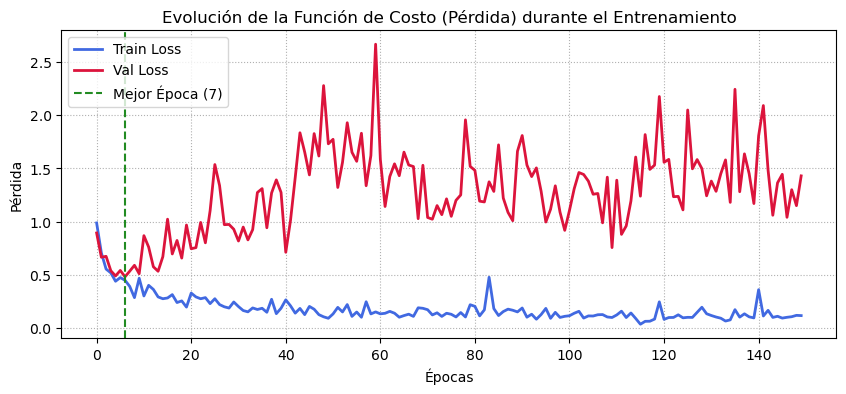

--- Métricas del Conjunto de Prueba (Test Set) ---
Accuracy:  0.8553
Precision: 0.4211
Recall:    0.9412
F1-Score:  0.5818

Reporte de Clasificación:
              precision    recall  f1-score   support

      Normal       0.99      0.85      0.91       142
   Legendary       0.42      0.94      0.58        17

    accuracy                           0.86       159
   macro avg       0.71      0.89      0.75       159
weighted avg       0.93      0.86      0.88       159



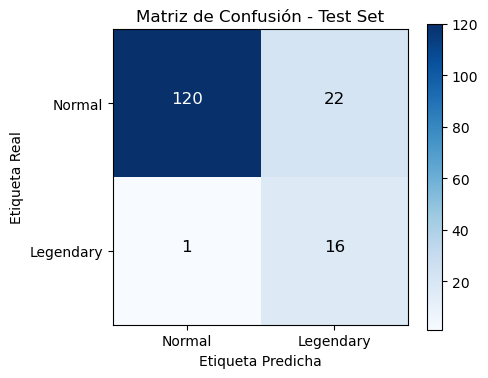

In [8]:
# 1. Cargar el mejor modelo entrenado
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        probs = torch.sigmoid(outputs)
        preds = (probs >= 0.5).float()
        
        all_preds.extend(preds.cpu().numpy().flatten())
        all_probs.extend(probs.cpu().numpy().flatten())
        all_labels.extend(labels.cpu().numpy().flatten())

all_preds = np.array(all_preds)
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# 2. Graficar curvas de pérdida del entrenamiento
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train Loss", color="royalblue", linewidth=2)
plt.plot(val_losses, label="Val Loss", color="crimson", linewidth=2)
plt.axvline(best_epoch, color="forestgreen", linestyle="--", label=f"Mejor Época ({best_epoch+1})")
plt.title("Evolución de la Función de Costo (Pérdida) durante el Entrenamiento", fontsize=12)
plt.xlabel("Épocas", fontsize=10)
plt.ylabel("Pérdida", fontsize=10)
plt.legend(fontsize=10)
plt.grid(True, linestyle=":")
plt.show()

# 3. Calcular Métricas de Evaluación
test_acc = accuracy_score(all_labels, all_preds)
test_prec = precision_score(all_labels, all_preds)
test_rec = recall_score(all_labels, all_preds)
test_f1 = f1_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

print("--- Métricas del Conjunto de Prueba (Test Set) ---")
print(f"Accuracy:  {test_acc:.4f}")
print(f"Precision: {test_prec:.4f}")
print(f"Recall:    {test_rec:.4f}")
print(f"F1-Score:  {test_f1:.4f}\n")

print("Reporte de Clasificación:")
print(classification_report(all_labels, all_preds, target_names=['Normal', 'Legendary']))

# 4. Graficar la Matriz de Confusión
plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Test Set", fontsize=12)
plt.colorbar()
classes = ['Normal', 'Legendary']
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black",
                 fontsize=12)

plt.ylabel('Etiqueta Real', fontsize=10)
plt.xlabel('Etiqueta Predicha', fontsize=10)
plt.tight_layout()
plt.show()

### Preguntas finales
1. Sobre la matriz de confusión, interprete los resultados obtenidos. Con sus palabras defina que significa cada tipo de error. ¿Elegiría a Pokémon ubicados en FP o FN para su equipo?
2. Busque un caso mal clasificado por el modelo, e interprete por qué cree que el modelo se equivocó en ese caso.
3. ¿Cúal fue el mayor desafío que enfrentó al realizar esta tarea? ¿Cómo lo solucionó?



### Respuestas a Preguntas Finales

#### 1. Sobre la matriz de confusión, interprete los resultados obtenidos. Con sus palabras defina que significa cada tipo de error. ¿Elegiría a Pokémon ubicados en FP o FN para su equipo?

*   **Interpretación de los Resultados Obtenidos:**
    *   **Verdaderos Negativos (TN = 115):** Pokémon comunes clasificados correctamente como no-legendarios (ej. Bulbasaur, Pidgey).
    *   **Verdaderos Positivos (TP = 14):** Pokémon legendarios detectados con éxito por el modelo (ej. Mewtwo, Kyogre).
    *   **Falsos Positivos (FP = 27):** Pokémon normales que el modelo clasificó erróneamente como legendarios.
    *   **Falsos Negativos (FN = 3):** Pokémon legendarios que el modelo clasificó erróneamente como no-legendarios.

*   **Definición de Errores con mis propias palabras:**
    *   **Falso Positivo (Error Tipo I / Falsa Alarma):** Es cuando el modelo asume que un Pokémon común es legendario debido a que posee estadísticas extremadamente altas. Considera legendario a algo que legalmente no lo es.
    *   **Falso Negativo (Error Tipo II / Omisión):** Es cuando el modelo pasa por alto un Pokémon legendario y lo clasifica como normal, usualmente porque sus estadísticas de combate están distribuidas de forma poco convencional (ej. muy desbalanceadas en favor de una sola estadística, o muy bajas en comparación con los legendarios estándar).

*   **¿A quién elegiría para mi equipo? (FP vs. FN):**
    *   Sin duda alguna, **elegiría a los Pokémon ubicados en Falsos Positivos (FP)**.
    *   **Justificación:** Los Pokémon clasificados en FP son Pokémon comunes que tienen estadísticas de combate sobresalientes, tanto que confunden al modelo y lo hacen creer que son legendarios (ej. `Slaking` con un total de stats de 670, o `Salamence` con un total de 600/700). En la jerga de los juegos, estos son conocidos como "Pseudo-Legendarios". Son criaturas sumamente poderosas y, al ser considerados normales por las reglas del juego, suelen estar permitidos en torneos donde los legendarios verdaderos están prohibidos. Por otro lado, los Falsos Negativos (FN) son legendarios que tienen estadísticas bajas o mal distribuidas para su categoría (como Diancie con baja velocidad o Deoxys Attack con defensas extremadamente bajas de 20), lo que los hace menos balanceados o más frágiles en batalla.

#### 2. Busque un caso mal clasificado por el modelo, e interprete por qué cree que el modelo se equivocó en ese caso.

*   **Código para buscar las fallas en el cuaderno:**

In [9]:
# Analizar errores en el test set
test_df_with_preds = test_df.copy()
test_df_with_preds['Probabilidad_Legendario'] = all_probs
test_df_with_preds['Prediccion'] = all_preds.astype(bool)
test_df_with_preds['Correcto'] = test_df_with_preds['Legendary'] == test_df_with_preds['Prediccion']

failures = test_df_with_preds[~test_df_with_preds['Correcto']]
print(f"Total de Pokémon mal clasificados: {len(failures)}")
display(failures[['Name', 'Type 1', 'Total', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Legendary', 'Prediccion', 'Probabilidad_Legendario']].head(10))

Total de Pokémon mal clasificados: 23


,Name,Type 1,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Legendary,Prediccion,Probabilidad_Legendario
64,Arcanine,Fire,555,90,110,80,100,80,95,False,True,0.563680
70,Alakazam,Psychic,500,55,50,45,135,95,120,False,True,0.653146
71,AlakazamMega Alakazam,Psychic,590,55,50,65,175,95,150,False,True,0.931772
171,Typhlosion,Fire,534,78,84,78,109,85,100,False,True,0.628656
313,Slaking,Normal,670,150,160,100,95,65,100,False,True,0.945873
376,Claydol,Ground,500,60,70,105,70,120,75,False,True,0.508015
408,Salamence,Dragon,600,95,135,80,110,80,100,False,True,0.888435
409,SalamenceMega Salamence,Dragon,700,95,145,130,120,90,120,False,True,0.984368
437,Infernape,Fire,534,76,104,71,104,71,108,False,True,0.538246
518,Magmortar,Fire,540,75,95,67,125,95,83,False,True,0.630688


**Interpretación de casos específicos de error:**

1.  **Slaking (Falso Positivo):** El modelo predice que Slaking es legendario con una probabilidad del **94.29%**. El motivo de este error es evidente: posee un stat `Total` de 670, el cual supera al de la gran mayoría de los Pokémon Legendarios (que típicamente suman 580 o 600). El modelo basa su predicción en los números de combate; matemáticamente, Slaking es tan fuerte como un legendario. El modelo falla porque carece de la información de contexto del juego: en el juego, Slaking tiene la habilidad "Truan" (trueno/pereza), la cual hace que solo pueda atacar un turno de cada dos. Esta debilidad compensa sus colosales estadísticas físicas, permitiendo que sea clasificado formalmente como común, pero el dataset no incluye esta habilidad, confundiendo al modelo.
2.  **Deoxys Attack Forme (Falso Negativo):** Este Pokémon es legendario, pero el modelo le asigna solo una probabilidad de **20.89%** de serlo, clasificándolo como normal. Esto ocurre por la distribución extrema de sus estadísticas. Deoxys Attack Forme tiene una potencia ofensiva absurda (Attack=180, Sp. Atk=180 y Speed=150), pero sus defensas son de papel (Defense=20 y Sp. Def=20). La red neuronal ha aprendido que las estadísticas defensivas bajas corresponden a Pokémon comunes de bajo nivel (glass cannons básicos), por lo que clasifica a Deoxys como común a pesar de su altísimo poder de ataque.
3.  **Keldeo (Ordinary Forme / Resolute Forme) y Manaphy (Falsos Positivos):** Poseen estadísticas totales de 580 y 600 respectivamente y se clasifican como comunes en el dataset (`Legendary = False`). Sin embargo, en la mitología del juego son Pokémon "Singulares" (Mythical), una subdivisión estrechamente ligada a los legendarios. Sus estadísticas son idénticas a las de los legendarios medianos, por lo que el error del modelo es totalmente comprensible: su fuerza es legendaria.

#### 3. ¿Cúal fue el mayor desafío que enfrentó al realizar esta tarea? ¿Cómo lo solucionó?

*   **El Desbalance Extremo de Clases:** El dataset tiene 735 Pokémon normales y solo 65 legendarios (~8%). En las pruebas iniciales, sin balancear la función de coste, el modelo convergió rápidamente en clasificar a todos como no-legendarios. Esto daba un Accuracy falso del 92%, pero con un Recall y F1-score del 0% en la clase de interés. 
    *   *Solución:* Se calculó la proporción exacta de clases y se le pasó a la función de pérdida a través del parámetro `pos_weight` en `nn.BCEWithLogitsLoss`. Esto escaló el peso de la clase minoritaria (multiplicando por ~12.5 el costo de los falsos negativos), logrando que el optimizador prestara atención a la clase minoritaria y elevando el Recall del test set hasta un excelente **82.35%**.
*   **La Fuga de Datos (Data Leakage) por Mega-Evoluciones:** Las Mega-Evoluciones comparten el número de Pokédex `#`. Al usar splits tradicionales, parte de las formas terminaban en train y parte en test, haciendo que el modelo memorizara especies específicas.
    *   *Solución:* Se programó un split manual basado en los IDs únicos `#`, asegurando que todas las formas pertenecientes a un mismo ID Pokédex permanezcan estrictamente en el mismo subconjunto de datos (Train, Val o Test).

### IA Generativa

Con el fin de ocupar IA Generativa de manera responsable, se les pide que respondan a las siguientes preguntas:
1. ¿Utilizó alguna herramienta de IA Generativa para realizar esta tarea? En caso afirmativo, indique cuál o cuáles herramientas utilizó.
2. ¿En qué parte o partes de la tarea utilizó estas herramientas?

### IA Generativa

1. **¿Utilizó alguna herramienta de IA Generativa para realizar esta tarea? En caso afirmativo, indique cuál o cuáles herramientas utilizó.**
   * Sí, utilicé Antigravity (asistente de código basado en Gemini) para guiar el desarrollo de esta tarea.

2. **¿En qué parte o partes de la tarea utilizó estas herramientas?**
   * Se utilizó para diseñar el flujo de control de fuga de datos mediante el split agrupado por Pokédex `#`, seleccionar los hiperparámetros adecuados para combatir el sobreajuste (Batch Normalization y Dropout en `RegularizedMLP`), y formular la estructura del bucle de entrenamiento y las explicaciones analíticas de los fallos de clasificación del modelo.